In [ ]:
import kagglehub
path = kagglehub.dataset_download("abdallahalidev/plantvillage-dataset")

Using Colab cache for faster access to the 'plantvillage-dataset' dataset.


In [ ]:
# Set seeds for reproducibility
import random
random.seed(0)

import numpy as np
np.random.seed(0)

import tensorflow as tf
tf.random.set_seed(0)

In [ ]:
import os
import json
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

In [ ]:
# Dataset Path
base_dir = '/kaggle/input/plantvillage-dataset/plantvillage dataset/color'

(256, 256, 3)


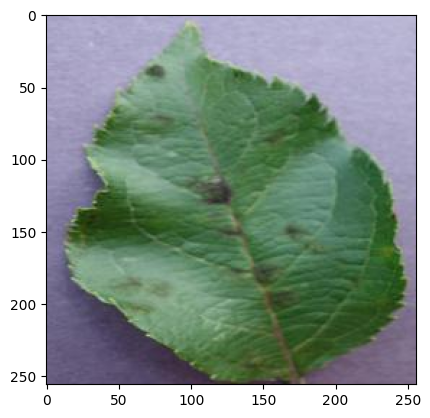

In [ ]:
image_path = '/kaggle/input/plantvillage-dataset/plantvillage dataset/color/Apple___Apple_scab/00075aa8-d81a-4184-8541-b692b78d398a___FREC_Scab 3335.JPG'

# Read the image
img = mpimg.imread(image_path)

print(img.shape)
# Display the image
plt.imshow(img)
plt.show()

In [ ]:
# Image Parameters
img_size = 224
batch_size = 32

In [ ]:
# Image Data Generators
data_gen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [ ]:
# Train Generator
train_generator = data_gen.flow_from_directory(
    base_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    subset='training',
    class_mode='categorical'
)

Found 43456 images belonging to 38 classes.


In [ ]:
# Validation Generator
validation_generator = data_gen.flow_from_directory(
    base_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    subset='validation',
    class_mode='categorical'
)

Found 10849 images belonging to 38 classes.


In [ ]:
# Model Definition
model = models.Sequential()

model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(img_size, img_size, 3)))
model.add(layers.MaxPooling2D(2, 2))

model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D(2, 2))


model.add(layers.Flatten())
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dense(train_generator.num_classes, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    47,776,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,805,158 (182.36 MB)

 Trainable params: 47,805,158 (182.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile the Model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
# Training the Model
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    epochs=5,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // batch_size
)

Epoch 1/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 291s 210ms/step - accuracy: 0.7451 - loss: 0.9066 - val_accuracy: 0.8592 - val_loss: 0.4425
Epoch 2/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 117s 86ms/step - accuracy: 0.9201 - loss: 0.2495 - val_accuracy: 0.8708 - val_loss: 0.4303
Epoch 3/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 111s 82ms/step - accuracy: 0.9608 - loss: 0.1187 - val_accuracy: 0.8737 - val_loss: 0.4520
Epoch 4/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 114s 84ms/step - accuracy: 0.9747 - loss: 0.0784 - val_accuracy: 0.8768 - val_loss: 0.5136
Epoch 5/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 109s 80ms/step - accuracy: 0.9808 - loss: 0.0614 - val_accuracy: 0.8756 - val_loss: 0.5907


In [ ]:
model.save('/content/drive/MyDrive/plant_disease_classifier.keras')

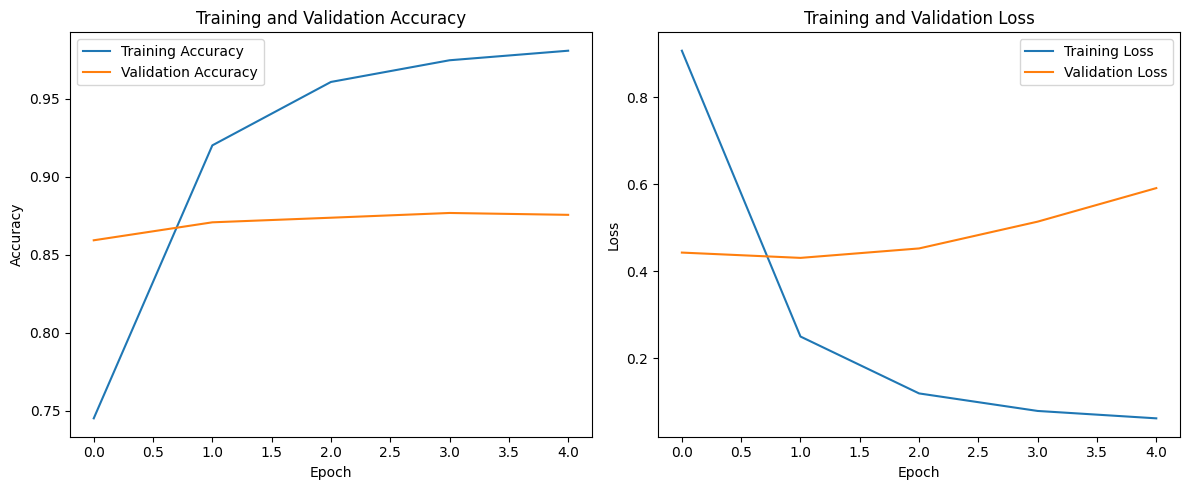

In [ ]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy curves
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training and validation loss curves
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:

model_with_dropout = models.Sequential()

model_with_dropout.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(img_size, img_size, 3)))
model_with_dropout.add(layers.MaxPooling2D(2, 2))
model_with_dropout.add(layers.Dropout(0.25))

model_with_dropout.add(layers.Conv2D(64, (3, 3), activation='relu'))
model_with_dropout.add(layers.MaxPooling2D(2, 2))
model_with_dropout.add(layers.Dropout(0.25))

model_with_dropout.add(layers.Flatten())
model_with_dropout.add(layers.Dense(256, activation='relu'))
model_with_dropout.add(layers.Dropout(0.5))
model_with_dropout.add(layers.Dense(train_generator.num_classes, activation='softmax'))

model_with_dropout.summary()


model_with_dropout.compile(optimizer='adam',
                           loss='categorical_crossentropy',
                           metrics=['accuracy'])

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │    47,776,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,805,158 (182.36 MB)

 Trainable params: 47,805,158 (182.36 MB)

 Non-trainable params: 0 (0.00 B)

**Early Stopping** is a form of regularization used to avoid overfitting when training a learner with an iterative method, such as gradient descent. It monitors a validation metric (like `val_loss` or `val_accuracy`) during training and stops the training process when the monitored metric stops improving, or even starts getting worse, for a certain number of epochs (patience). This prevents the model from continuing to learn the training data's noise.

Epoch 1/20
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 122s 90ms/step - accuracy: 0.8071 - loss: 0.5939 - val_accuracy: 0.8686 - val_loss: 0.4283
Epoch 2/20
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 110s 81ms/step - accuracy: 0.8265 - loss: 0.5308 - val_accuracy: 0.8653 - val_loss: 0.4366
Epoch 3/20
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 119s 88ms/step - accuracy: 0.8437 - loss: 0.4751 - val_accuracy: 0.8703 - val_loss: 0.4123
Epoch 4/20
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 121s 89ms/step - accuracy: 0.8582 - loss: 0.4295 - val_accuracy: 0.8771 - val_loss: 0.4039
Epoch 5/20
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 113s 83ms/step - accuracy: 0.8692 - loss: 0.3939 - val_accuracy: 0.8786 - val_loss: 0.4060
Epoch 6/20
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 111s 82ms/step - accuracy: 0.8748 - loss: 0.3741 - val_accuracy: 0.8638 - val_loss: 0.4547
Epoch 7/20
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 112s 83ms/step - accuracy: 0.8875 - loss: 0.3372 - val_accuracy: 0.8744 - val_loss: 0.4252
Epoch 7: early stopping
Restoring model weights from the end of the b

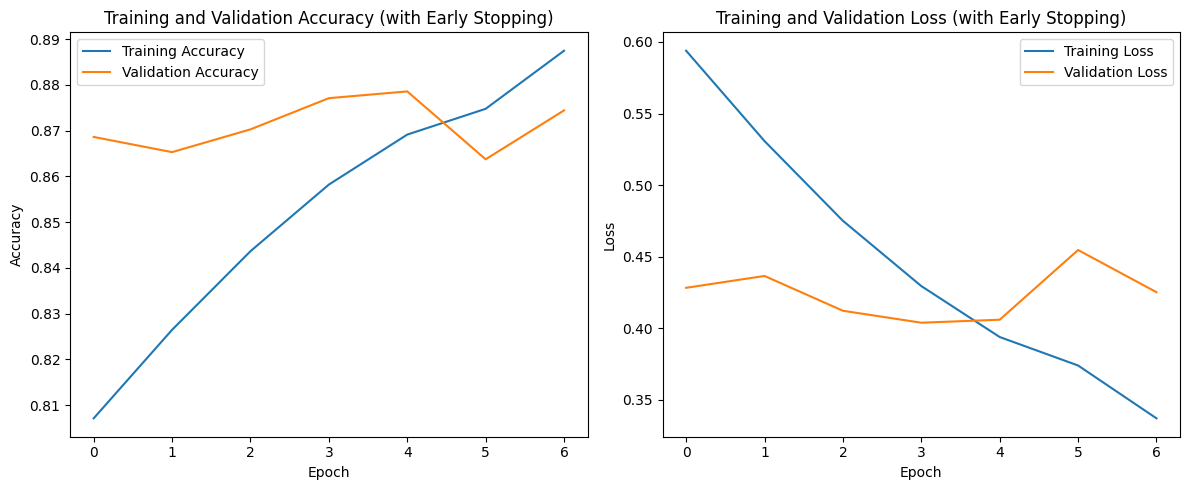

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

history_with_early_stopping = model_with_dropout.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    epochs=20,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // batch_size,
    callbacks=[early_stopping]
)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_with_early_stopping.history['accuracy'], label='Training Accuracy')
plt.plot(history_with_early_stopping.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy (with Early Stopping)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_with_early_stopping.history['loss'], label='Training Loss')
plt.plot(history_with_early_stopping.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss (with Early Stopping)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
model_with_dropout.save('/content/drive/MyDrive/plant_disease_final_model.keras')